<a href="https://colab.research.google.com/github/Keshabbu/Datascience/blob/main/Exercise_05_Multiple_Linear_Regression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WS - Multiple Linear Regression

## Exercise 5: Predicting energy consumption

##### **Objective:**

Predict the “Annual Energy Consumption” for buildings using multiple linear regression.

##### **Dataset:**

Use the "building_energy.csv" which is self generated. The dataset contains 10.000 samples with 4 features, and the
target variable is the Annual Energy Consumption.

1. Import the necessary libraries: pandas, numpy, matplotlib, and scikit-learn.
2. Conduct basic EDA (Exploratory Data Analysis: histograms of features, scatter plot matrix, check for missing values)
3. Create a multiple linear regression model with all features predicting the target variable.
4. Compute a MAE on a suitable test set.
5. Check the features for correlation. What does the correlation tell us? How can it be used?
6. Which feature has the highest impact on the target variable?
7. Plot the target against the predictions. What does it tell us?

##### **Hints/reminders:**

- df.isnull() gives boolean dataframe for null-values
- df.sum() sums up given dataframe

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving building_energy.csv to building_energy.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('building_energy.csv',sep=';',decimal=',')
df.head()

,Building Size,Number of Floors,Average Floor Size,Annual Energy Consumption,building_size_squarefeet
0,202,3,67.333333,3730.911967,18.766432
1,535,6,89.166667,11498.159841,49.703174
2,960,4,240.000000,19284.883963,89.187005
3,370,9,41.111111,7514.762477,34.374158
4,206,7,29.428571,5305.672142,19.138045


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Building Size              10000 non-null  int64  
 1   Number of Floors           10000 non-null  int64  
 2   Average Floor Size         10000 non-null  float64
 3   Annual Energy Consumption  10000 non-null  float64
 4   building_size_squarefeet   10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


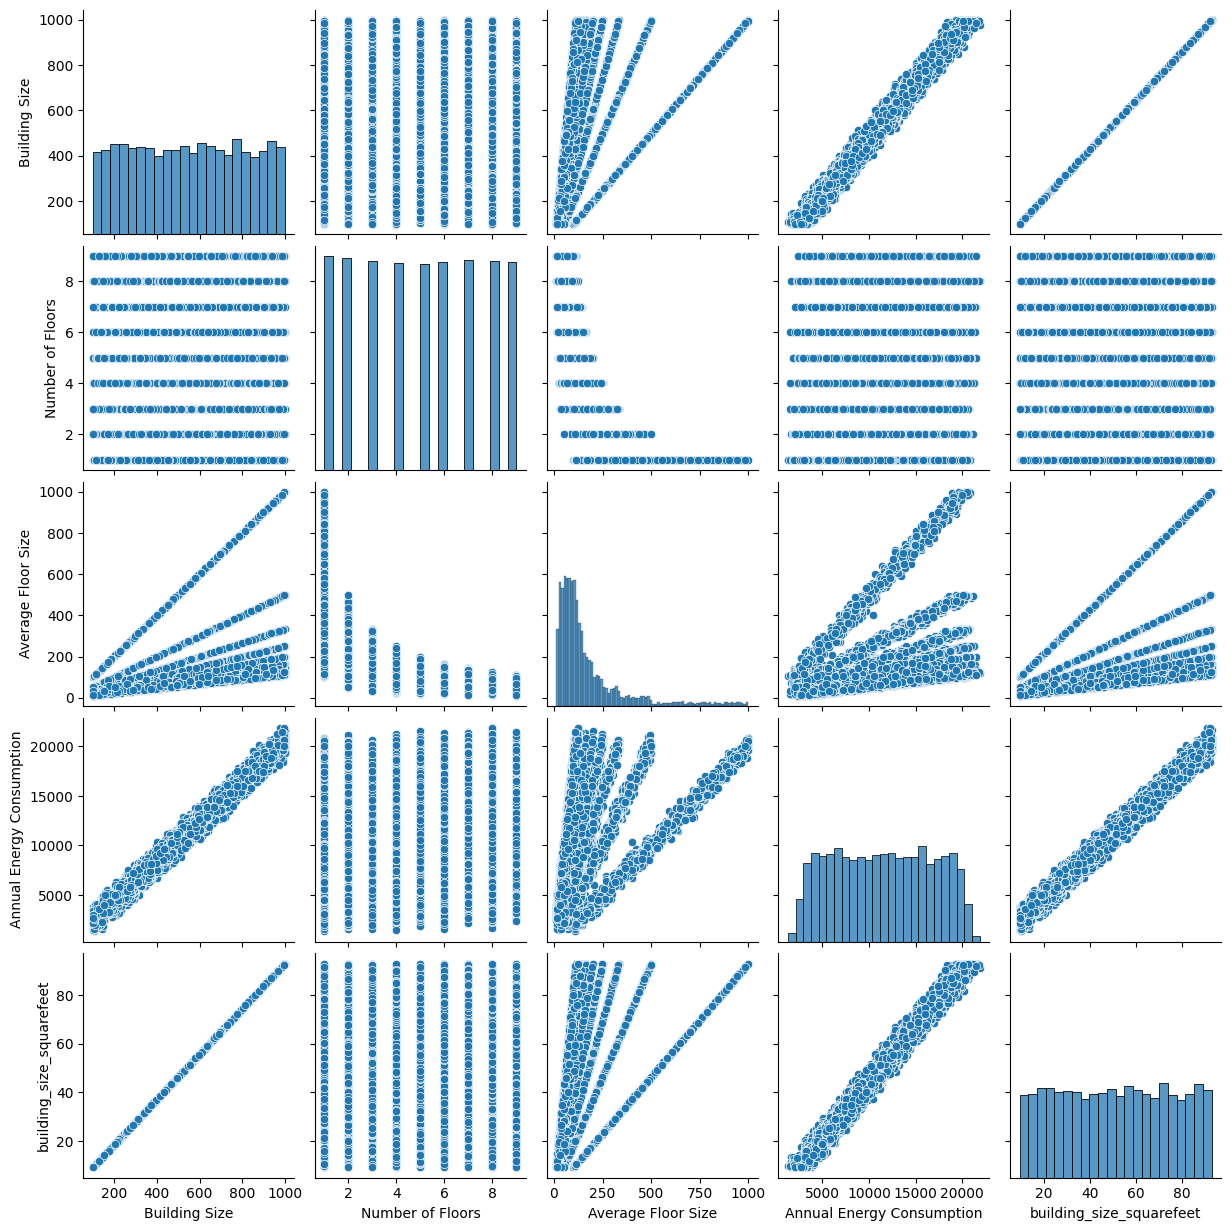

In [ ]:
import seaborn as sns
sns.pairplot(df)


In [ ]:
df.columns

Index(['Building Size', 'Number of Floors', 'Average Floor Size',
       'Annual Energy Consumption', 'building_size_squarefeet'],
      dtype='object')

In [ ]:
X = df[['Building Size', 'Number of Floors', 'Average Floor Size',
       'Annual Energy Consumption', 'building_size_squarefeet']]
y= df['Annual Energy Consumption']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size=0.2, random_state=42)

In [ ]:
X

,Building Size,Number of Floors,Average Floor Size,Annual Energy Consumption,building_size_squarefeet
0,202,3,67.333333,3730.911967,18.766432
1,535,6,89.166667,11498.159841,49.703174
2,960,4,240.000000,19284.883963,89.187005
3,370,9,41.111111,7514.762477,34.374158
4,206,7,29.428571,5305.672142,19.138045
...,...,...,...,...,...
9995,127,9,14.111111,3567.677171,11.798697
9996,432,6,72.000000,9653.145062,40.134152
9997,100,7,14.285714,2687.294315,9.290313
9998,287,8,35.875000,7274.606720,26.663198


In [ ]:
y

,Annual Energy Consumption
0,3730.911967
1,11498.159841
2,19284.883963
3,7514.762477
4,5305.672142
...,...
9995,3567.677171
9996,9653.145062
9997,2687.294315
9998,7274.606720


In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 5), (2000, 5), (8000,), (2000,))

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print('accuracy is ',sum(y_test == model.predict(X_test)/len(y_test)))

accuracy is  0


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print('mean absoulte errr is ',mae)

mean absoulte errr is  2.18153672904009e-12


In [ ]:
coefficient = pd.DataFrame(model.coef_,X.columns,columns=['coefficient'])
coefficient

,coefficient
Building Size,1.885050e-15
Number of Floors,-6.772360e-15
Average Floor Size,-2.428613e-17
Annual Energy Consumption,1.000000e+00
building_size_squarefeet,1.752071e-16


In [ ]:
corr_metrix = df.corr()
corr_metrix

,Building Size,Number of Floors,Average Floor Size,Annual Energy Consumption,building_size_squarefeet
Building Size,1.000000,-0.018215,0.452523,0.994148,1.000000
Number of Floors,-0.018215,1.000000,-0.670893,0.031149,-0.018215
Average Floor Size,0.452523,-0.670893,1.000000,0.416559,0.452523
Annual Energy Consumption,0.994148,0.031149,0.416559,1.000000,0.994148
building_size_squarefeet,1.000000,-0.018215,0.452523,0.994148,1.000000


<Axes: >

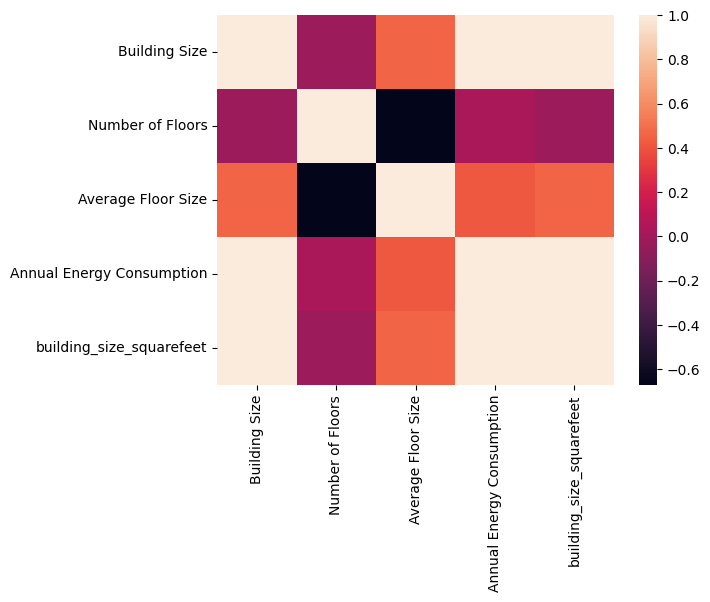

In [ ]:
sns.heatmap(corr_metrix)

In [ ]:
df2 = pd.read_csv('building_energy.csv',sep=';',decimal=',')
df2.head()

,Building Size,Number of Floors,Average Floor Size,Annual Energy Consumption,building_size_squarefeet
0,202,3,67.333333,3730.911967,18.766432
1,535,6,89.166667,11498.159841,49.703174
2,960,4,240.000000,19284.883963,89.187005
3,370,9,41.111111,7514.762477,34.374158
4,206,7,29.428571,5305.672142,19.138045


In [ ]:
X1 = df2[['Number of Floors', 'Average Floor Size',
       'Annual Energy Consumption', 'building_size_squarefeet']]
y1= df2['Annual Energy Consumption']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X1,y1, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred1 = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred1)
print('mean absoulte errr is ',mae)

mean absoulte errr is  2.0144170775893146e-12


In [ ]:
coefficient = pd.DataFrame(model.coef_,X1.columns,columns=['coefficient'])
coefficient

,coefficient
Number of Floors,-9.632393e-13
Average Floor Size,-1.865175e-14
Annual Energy Consumption,1.000000e+00
building_size_squarefeet,-5.412337e-15


<Axes: >

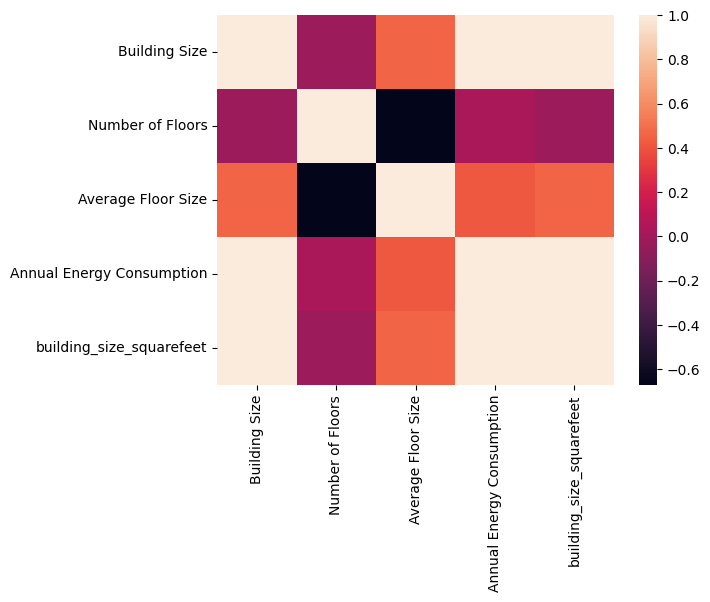

In [ ]:
sns.heatmap(corr_metrix)

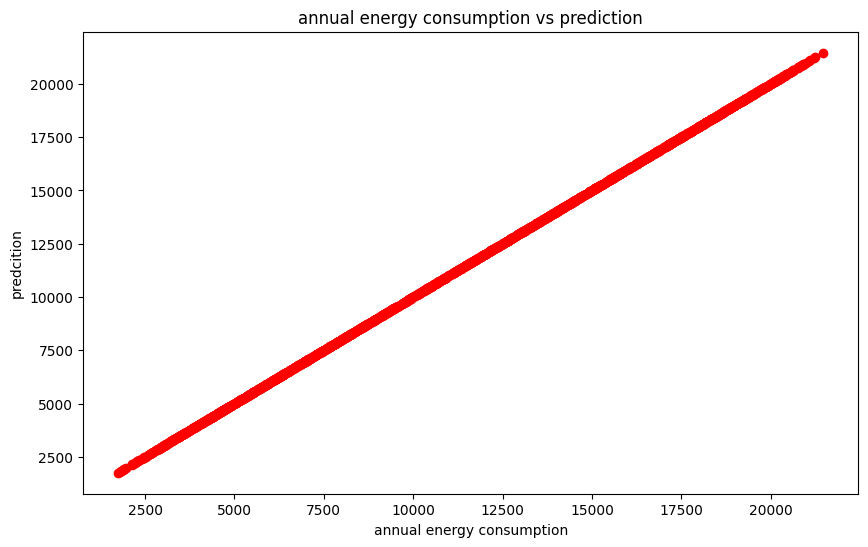

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred1,color= 'red')
plt.xlabel("annual energy consumption")
plt.ylabel('predcition')
plt.title('annual energy consumption vs prediction')
plt.show()